Initial Data:
         Date  Temperature  Humidity(%)  Wind\nSpeed\n(km/h)  Rainfall(mm)
0  01-01-2025         15.2           80                 10.5           0.0
1  02-01-2025         16.8           75                  8.0           0.0
2  03-01-2025         14.5           85                 12.0           1.2
3  04-01-2025         13.0           90                 15.2           5.4
4  05-01-2025         17.6           70                  7.4           0.0

Missing Values:
Date                   0
Temperature            0
Humidity(%)            0
Wind\nSpeed\n(km/h)    0
Rainfall(mm)           0
dtype: int64

Monthly Average Temperature:
Year  Month
2025  1        15.31
Name: Temperature, dtype: float64


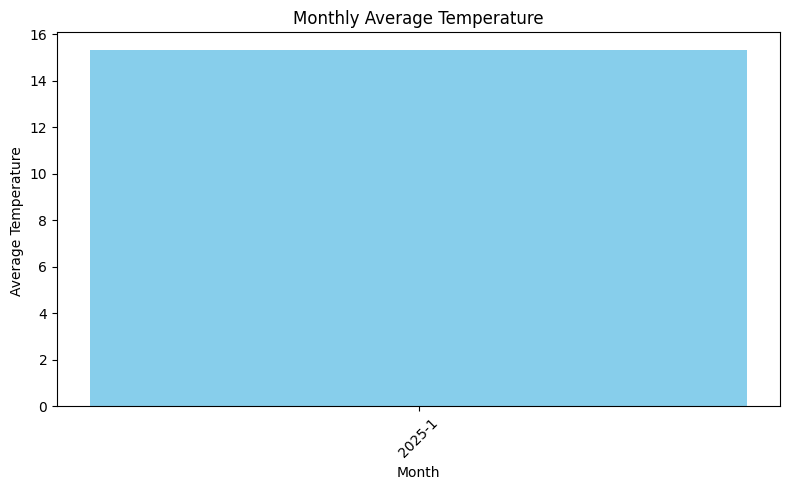

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "/content/sample_data/weather_data.csv"
df = pd.read_csv(file_path)

# Display first few rows
print("Initial Data:")
print(df.head())

# -----------------------------
# a. Check for missing values
# -----------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values
# Option 1: Fill missing numeric values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Option 2 (alternative): Drop rows with missing values
# df.dropna(inplace=True)

# -----------------------------
# Data preprocessing
# -----------------------------
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Extract month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# -----------------------------
# b. Average temperature per month
# -----------------------------
monthly_avg_temp = df.groupby(['Year', 'Month'])['Temperature'].mean()

print("\nMonthly Average Temperature:")
print(monthly_avg_temp)

# Reset index for plotting
monthly_avg_temp = monthly_avg_temp.reset_index()

# -----------------------------
# c. Visualization (Bar Plot)
# -----------------------------
plt.figure(figsize=(8, 5))

# Create labels like "2025-01"
labels = monthly_avg_temp['Year'].astype(str) + "-" + monthly_avg_temp['Month'].astype(str)

plt.bar(labels, monthly_avg_temp['Temperature'], color='skyblue')

plt.xlabel("Month")
plt.ylabel("Average Temperature ")
plt.title("Monthly Average Temperature")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()